# Outlier Analysis on Customer-Level Features

This notebook performs outlier detection on customer-level behavioral features built from the Instacart order data. It compares several detection techniques and visualises the flagged outliers in 2-D PCA space.

**Methods used**
1. Univariate: IQR rule and Z-score on each feature.
2. Multivariate: Mahalanobis distance, Isolation Forest, Local Outlier Factor (LOF).

**Outputs**
- Box-plot grid of all features with IQR fences.
- Histogram grid showing distribution + univariate outlier thresholds.
- 2-D PCA scatter plot for every multivariate method, with outliers highlighted.
- Agreement matrix between methods + a final "consensus outlier" CSV under `artifacts/`.

In [8]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import MinCovDet

sys.path.insert(0, os.path.abspath('..'))
from notebooks.utils import (
    DATA_DIR, ARTIFACTS_DIR, VIZ_DIR,
    ensure_dirs, save_figure, save_artifact,
)

ensure_dirs()
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Data dir       :', DATA_DIR)
print('Artifacts dir  :', ARTIFACTS_DIR)
print('Visualisations :', VIZ_DIR)

Data dir       : /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/data
Artifacts dir  : /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/artifacts
Visualisations : /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/visualizations


## 1. Build customer-level feature table

We aggregate per-user behaviour from `orders.csv` and `order_products__prior.csv` to produce the same six features used in the clustering pipeline:

| feature | meaning |
| --- | --- |
| `total_orders` | number of orders placed by the user |
| `avg_days_between_orders` | mean inter-order gap (days) |
| `avg_order_hour` | typical hour of day the user shops |
| `order_variability` | variance of the user's order numbers (proxy for cadence regularity) |
| `avg_basket_size` | average #items per basket |
| `reorder_rate` | fraction of items in baskets that are reorders |

In [9]:
orders = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'))
op_prior = pd.read_csv(
    os.path.join(DATA_DIR, 'order_products__prior.csv'),
    usecols=['order_id', 'reordered'],
)
print(f'orders            : {orders.shape}')
print(f'order_products__prior: {op_prior.shape}')

orders            : (3421083, 7)
order_products__prior: (32434489, 2)


In [10]:
user_lookup = orders[['order_id', 'user_id']]
op_user = op_prior.merge(user_lookup, on='order_id', how='inner')

basket_size = (
    op_user.groupby(['user_id', 'order_id']).size().rename('basket_size').reset_index()
)
avg_basket_size = (
    basket_size.groupby('user_id')['basket_size'].mean().rename('avg_basket_size').reset_index()
)
reorder_rate = (
    op_user.groupby('user_id')['reordered'].mean().rename('reorder_rate').reset_index()
)

customer_features = (
    orders.groupby('user_id').agg(
        total_orders=('order_number', 'max'),
        avg_days_between_orders=('days_since_prior_order', 'mean'),
        avg_order_hour=('order_hour_of_day', 'mean'),
        order_variability=('order_number', 'var'),
    )
    .reset_index()
    .merge(avg_basket_size, on='user_id', how='left')
    .merge(reorder_rate, on='user_id', how='left')
    .fillna(0)
)

FEATURES = [
    'total_orders',
    'avg_days_between_orders',
    'avg_order_hour',
    'order_variability',
    'avg_basket_size',
    'reorder_rate',
]
X_raw = customer_features[FEATURES].copy()
print(f'customer_features : {customer_features.shape}')
customer_features.head()

customer_features : (206209, 7)


,user_id,total_orders,avg_days_between_orders,avg_order_hour,order_variability,avg_basket_size,reorder_rate
0,1,11,19.000000,10.090909,11.000000,5.900000,0.694915
1,2,15,16.285714,10.600000,20.000000,13.928571,0.476923
2,3,13,12.000000,16.307692,15.166667,7.333333,0.625000
3,4,6,17.000000,12.500000,3.500000,3.600000,0.055556
4,5,5,11.500000,15.000000,2.500000,9.250000,0.378378


In [11]:
X_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,206209.0,16.590367,16.654774,4.000000,6.000000,10.000000,20.000000,100.000000
avg_days_between_orders,206209.0,15.448686,6.915575,0.000000,9.814815,15.000000,20.625000,30.000000
avg_order_hour,206209.0,13.585248,2.020743,0.750000,12.250000,13.571429,14.900000,23.000000
order_variability,206209.0,47.434232,110.421012,1.666667,3.500000,9.166667,35.000000,841.666667
avg_basket_size,206209.0,9.951586,5.863570,1.000000,5.740741,8.933333,13.000000,70.250000
reorder_rate,206209.0,0.432249,0.212144,0.000000,0.267857,0.428571,0.595745,0.989529


## 2. Univariate outlier detection

We start with one feature at a time. Two classical rules are applied:

- **IQR rule**: a point is an outlier if it falls outside `[Q1 - 1.5 IQR, Q3 + 1.5 IQR]`.
- **Z-score**: a point is an outlier if `|z| > 3` after standardisation.

Several features (`total_orders`, `order_variability`, `avg_basket_size`) are right-skewed, so we also display the log-scaled distribution to keep the visualisation readable.

In [13]:
def iqr_outlier_mask(series, k=1.5):
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (series < lo) | (series > hi), (lo, hi)

def zscore_outlier_mask(series, threshold=3.0):
    z = np.abs(stats.zscore(np.asarray(series), nan_policy='omit'))
    return z > threshold, threshold

univariate_summary_rows = []
iqr_masks, z_masks = {}, {}
for feat in FEATURES:
    iqr_mask, (lo, hi) = iqr_outlier_mask(X_raw[feat])
    z_mask, _ = zscore_outlier_mask(X_raw[feat])
    iqr_masks[feat] = np.asarray(iqr_mask)
    z_masks[feat] = np.asarray(z_mask)
    univariate_summary_rows.append({
        'feature': feat,
        'iqr_low': lo,
        'iqr_high': hi,
        'iqr_outliers': int(iqr_mask.sum()),
        'iqr_pct': round(100 * iqr_mask.mean(), 2),
        'z_outliers': int(z_mask.sum()),
        'z_pct': round(100 * z_mask.mean(), 2),
    })

univariate_summary = pd.DataFrame(univariate_summary_rows)
univariate_summary

,feature,iqr_low,iqr_high,iqr_outliers,iqr_pct,z_outliers,z_pct
0,total_orders,-15.000000,41.000000,17017,8.25,4991,2.42
1,avg_days_between_orders,-6.400463,36.840278,0,0.00,0,0.00
2,avg_order_hour,8.275000,18.875000,2409,1.17,1015,0.49
3,order_variability,-43.750000,82.250000,29183,14.15,4991,2.42
4,avg_basket_size,-5.148148,23.888889,5551,2.69,2548,1.24
5,reorder_rate,-0.223974,1.087576,0,0.00,0,0.00


Figure saved -> /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/visualizations/outlier_boxplots.png


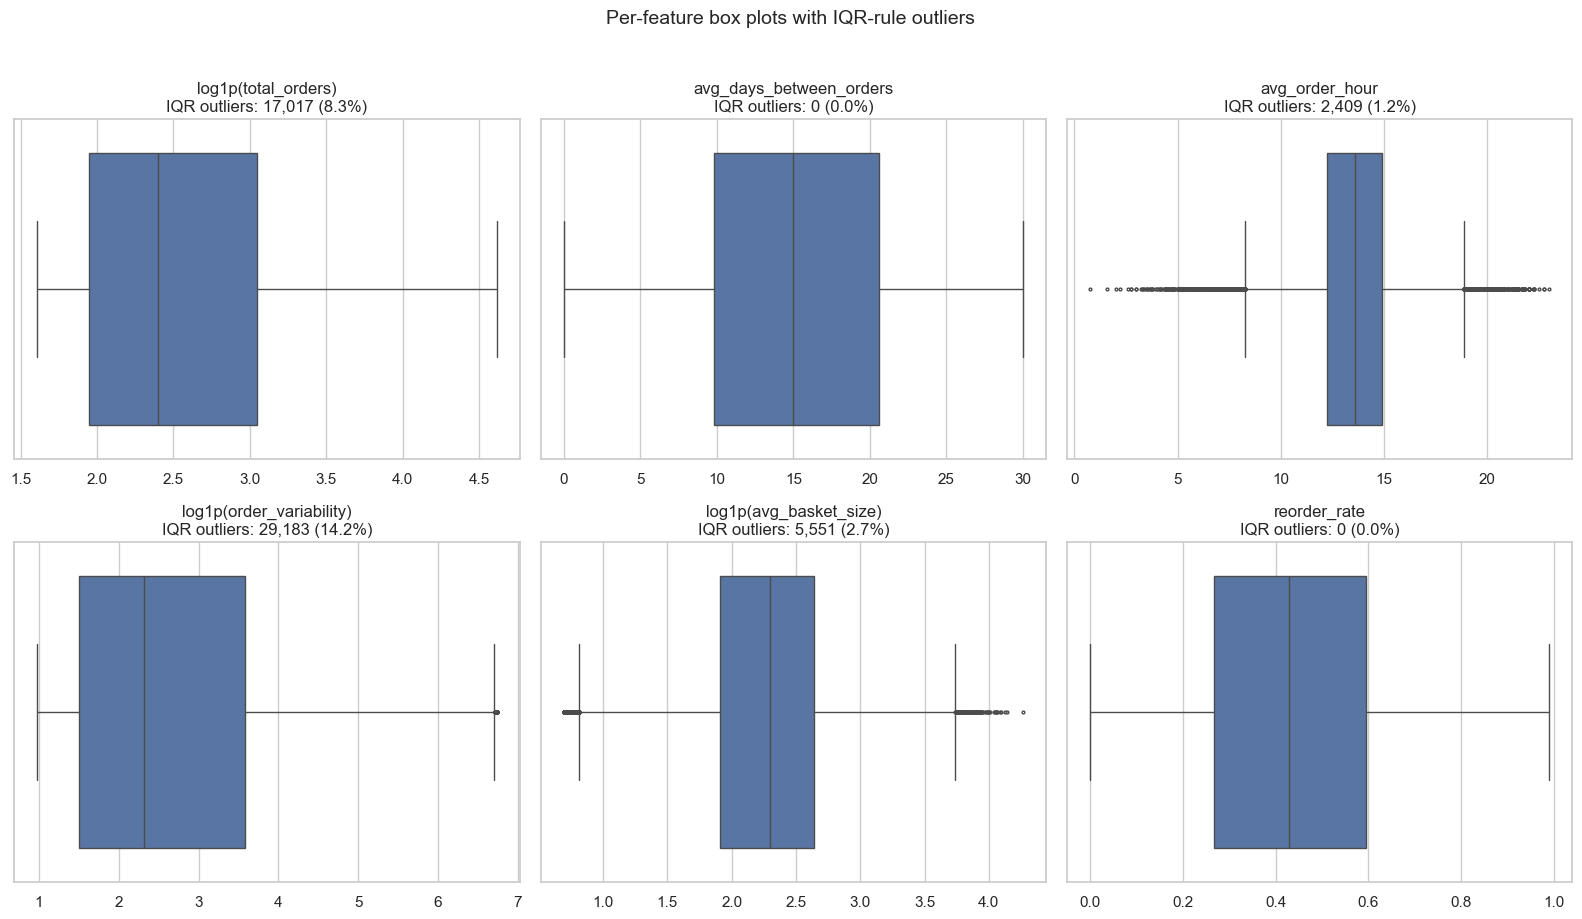

In [14]:
log_features = {'total_orders', 'order_variability', 'avg_basket_size'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.ravel(), FEATURES):
    data = np.log1p(X_raw[feat]) if feat in log_features else X_raw[feat]
    sns.boxplot(x=data, ax=ax, color='#4C72B0', fliersize=2)
    n_out = iqr_masks[feat].sum()
    label = f'log1p({feat})' if feat in log_features else feat
    ax.set_title(f'{label}\nIQR outliers: {n_out:,} ({n_out / len(X_raw):.1%})')
    ax.set_xlabel('')
fig.suptitle('Per-feature box plots with IQR-rule outliers', fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, 'outlier_boxplots.png')
plt.show()

Figure saved -> /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/visualizations/outlier_histograms.png


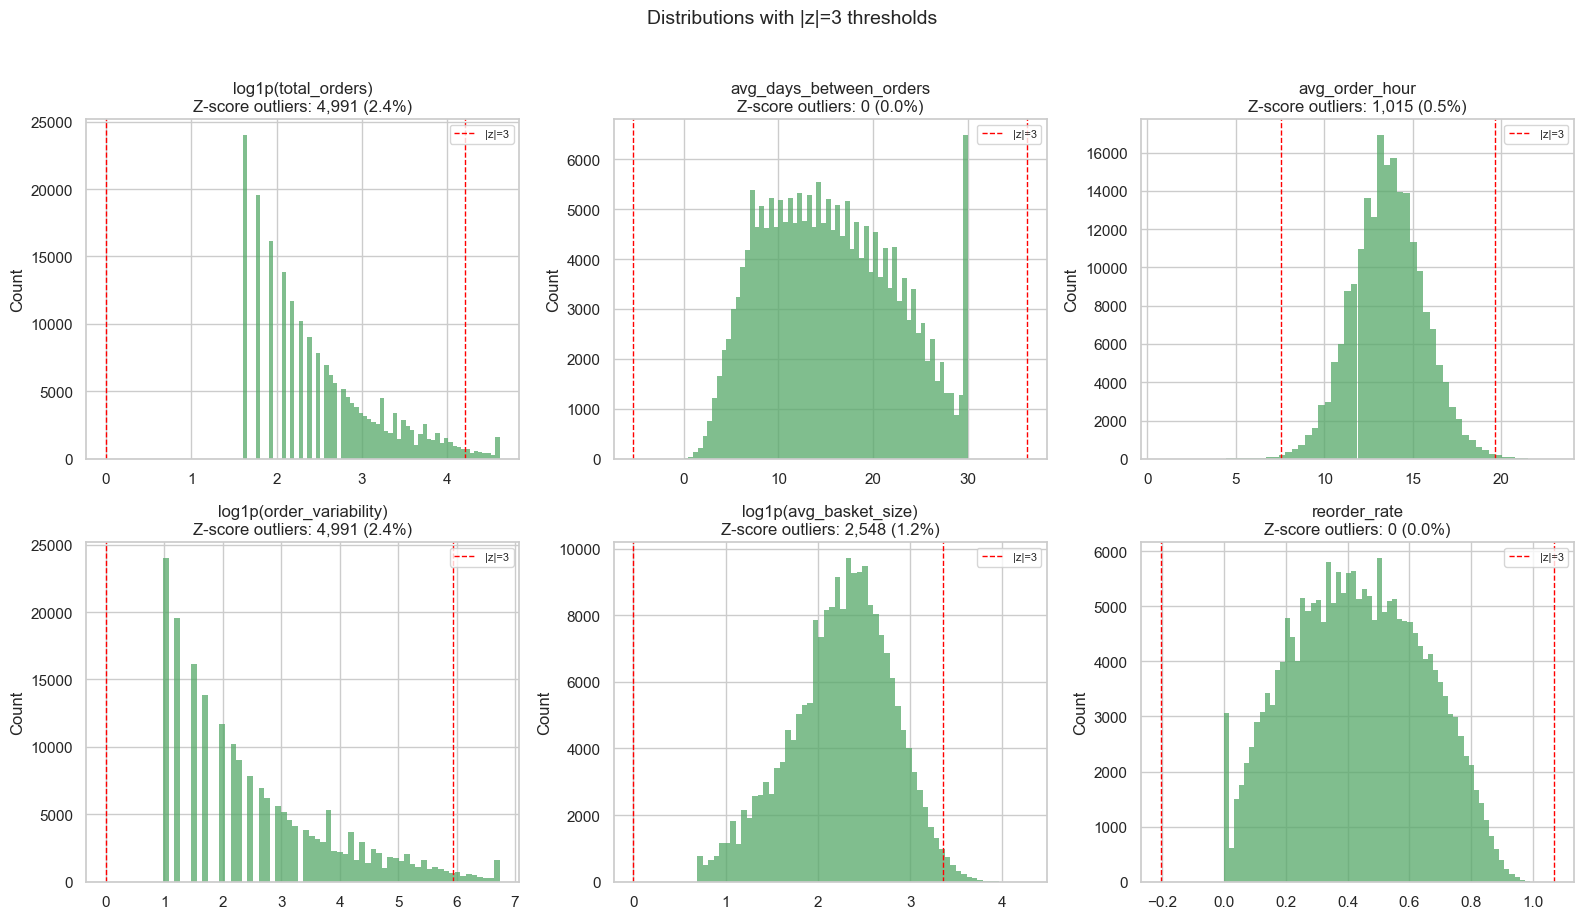

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.ravel(), FEATURES):
    series = X_raw[feat]
    plot_series = np.log1p(series) if feat in log_features else series
    sns.histplot(plot_series, bins=60, ax=ax, color='#55A868', edgecolor='none')
    mu, sigma = series.mean(), series.std()
    z_low, z_high = mu - 3 * sigma, mu + 3 * sigma
    if feat in log_features:
        z_low, z_high = np.log1p(max(z_low, 0)), np.log1p(max(z_high, 0))
    ax.axvline(z_low, color='red', linestyle='--', linewidth=1, label='|z|=3')
    ax.axvline(z_high, color='red', linestyle='--', linewidth=1)
    n_out = z_masks[feat].sum()
    label = f'log1p({feat})' if feat in log_features else feat
    ax.set_title(f'{label}\nZ-score outliers: {n_out:,} ({n_out / len(X_raw):.1%})')
    ax.set_xlabel('')
    ax.legend(loc='upper right', fontsize=8)
fig.suptitle('Distributions with |z|=3 thresholds', fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, 'outlier_histograms.png')
plt.show()

## 3. Multivariate outlier detection

Univariate rules ignore correlations between features. The following methods consider the full 6-D feature space.

All three are run on **log-transformed, standardised** features so that heavy-tailed counts (`total_orders`, `order_variability`, `avg_basket_size`) do not dominate the distance metric.

All three methods are calibrated to flag the **same fraction** (`contamination=0.02`, top 2 %) so their outputs can be compared directly.

| method | how it scores | outlier flag |
| --- | --- | --- |
| Mahalanobis distance (robust, MinCovDet) | distance from robust centroid | top 2 % of `d^2` |
| Isolation Forest | average isolation depth (shorter ⇒ more anomalous) | `predict == -1` (`contamination=0.02`) |
| Local Outlier Factor | local density vs. neighbours | `predict == -1` (`contamination=0.02`) |

For Mahalanobis we also report the strict `chi2_{0.975}(df=6)` cutoff for reference, which would normally classify any point exceeding the 97.5 % chi-square quantile as an outlier under multivariate normality.

In [16]:
X_log = X_raw.copy()
for feat in log_features:
    X_log[feat] = np.log1p(X_log[feat])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled.shape

(206209, 6)

In [17]:
CONTAMINATION = 0.02

robust_cov = MinCovDet(random_state=RANDOM_STATE).fit(X_scaled)
mahal_d2 = robust_cov.mahalanobis(X_scaled)
chi2_cutoff = stats.chi2.ppf(0.975, df=X_scaled.shape[1])
mahal_cutoff = np.quantile(mahal_d2, 1 - CONTAMINATION)
mahal_outlier = mahal_d2 > mahal_cutoff
print(f'Mahalanobis     : {mahal_outlier.sum():,} flagged ({mahal_outlier.mean():.2%}); cutoff d^2 = {mahal_cutoff:.2f} (chi2_0.975 reference = {chi2_cutoff:.2f})')

iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_scaled)
iso_score = -iso.decision_function(X_scaled)
iso_outlier = iso.predict(X_scaled) == -1
print(f'Isolation Forest: {iso_outlier.sum():,} flagged ({iso_outlier.mean():.2%})')

lof = LocalOutlierFactor(n_neighbors=35, contamination=CONTAMINATION, n_jobs=-1)
lof_pred = lof.fit_predict(X_scaled)
lof_score = -lof.negative_outlier_factor_
lof_outlier = lof_pred == -1
print(f'LOF             : {lof_outlier.sum():,} flagged ({lof_outlier.mean():.2%})')

Mahalanobis     : 4,125 flagged (2.00%); cutoff d^2 = 696.77 (chi2_0.975 reference = 14.45)
Isolation Forest: 4,125 flagged (2.00%)
LOF             : 4,125 flagged (2.00%)


## 4. Visualise outliers in 2-D PCA space

We project the 6-D scaled features down to 2 principal components purely for visualisation. Each panel shows the same point cloud; only the colouring (outlier vs. inlier) changes.

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance ratio (PC1, PC2):', np.round(pca.explained_variance_ratio_, 3))
print('Cumulative explained:', round(pca.explained_variance_ratio_.sum(), 3))

Explained variance ratio (PC1, PC2): [0.524 0.176]
Cumulative explained: 0.7


Figure saved -> /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/visualizations/outliers_pca_methods.png


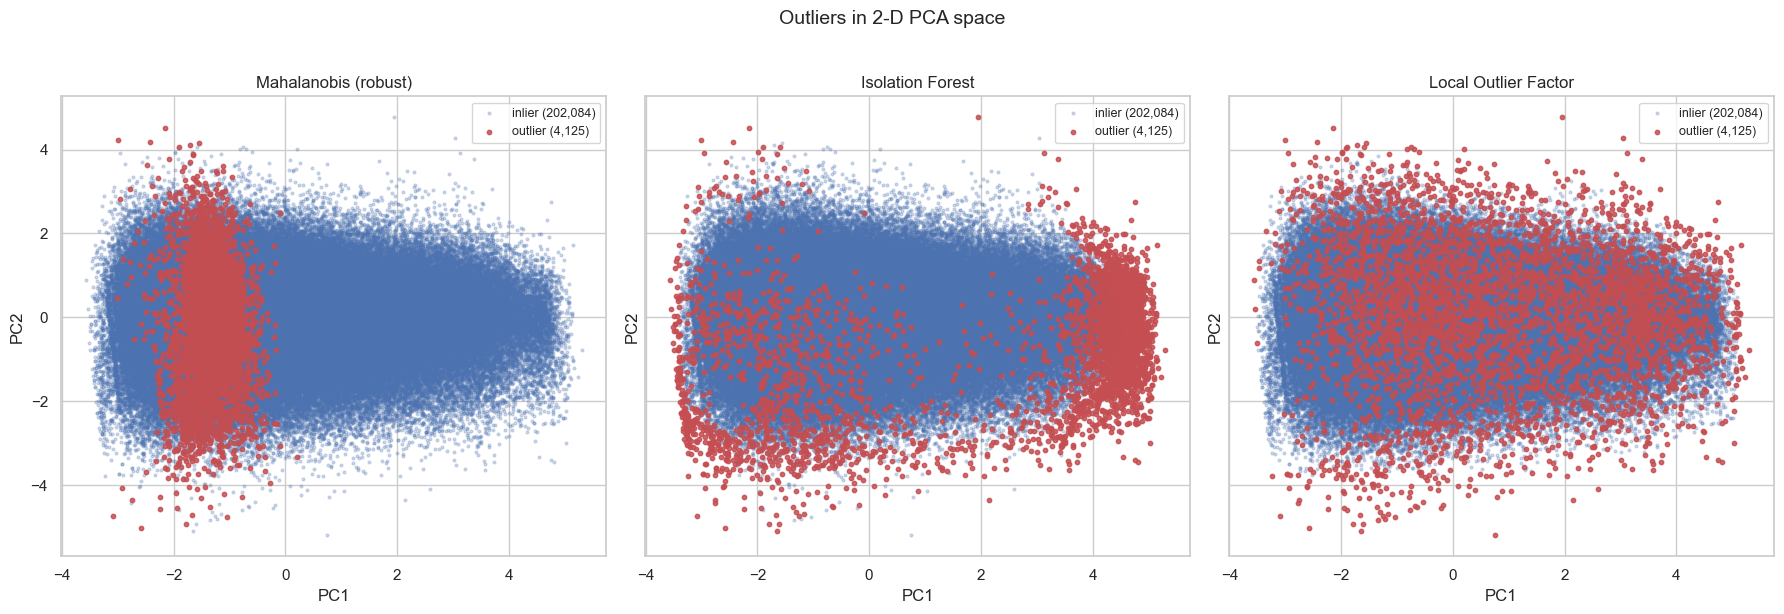

In [19]:
method_masks = {
    'Mahalanobis (robust)': mahal_outlier,
    'Isolation Forest': iso_outlier,
    'Local Outlier Factor': lof_outlier,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
for ax, (name, mask) in zip(axes, method_masks.items()):
    ax.scatter(
        X_pca[~mask, 0], X_pca[~mask, 1],
        s=4, alpha=0.25, color='#4C72B0', label=f'inlier ({(~mask).sum():,})',
    )
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=10, alpha=0.85, color='#C44E52', label=f'outlier ({mask.sum():,})',
    )
    ax.set_title(name)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='upper right', fontsize=9)
fig.suptitle('Outliers in 2-D PCA space', fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, 'outliers_pca_methods.png')
plt.show()

Figure saved -> /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/visualizations/outlier_score_heatmaps.png


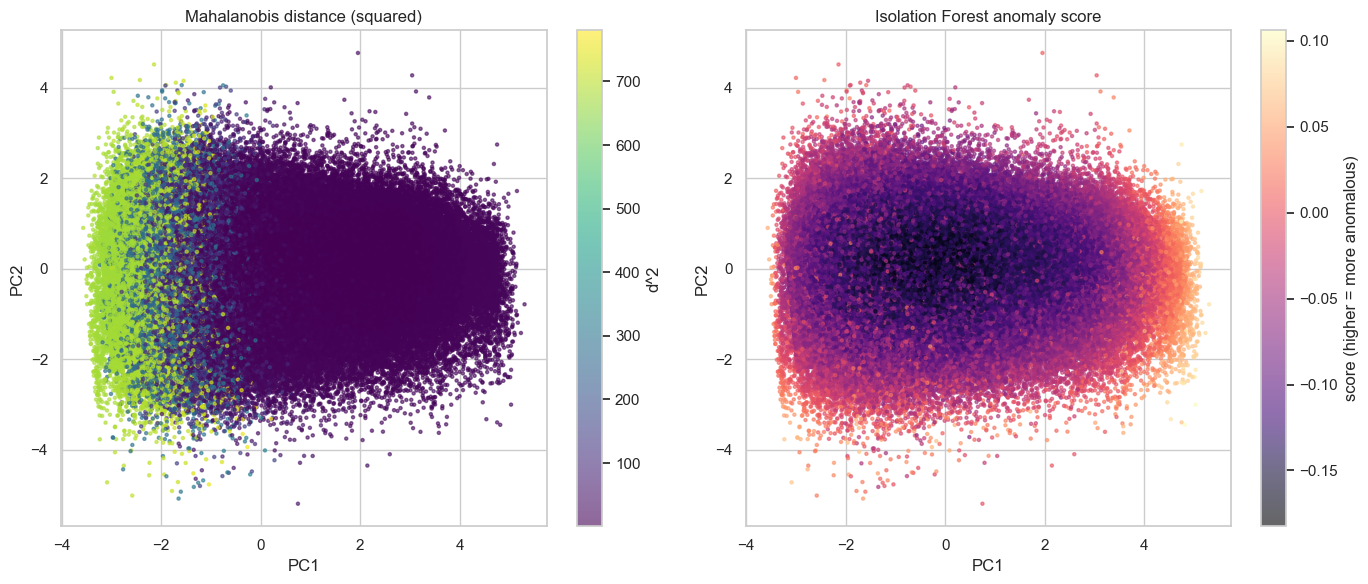

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=mahal_d2, cmap='viridis', s=5, alpha=0.6)
axes[0].set_title('Mahalanobis distance (squared)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
fig.colorbar(sc0, ax=axes[0], label='d^2')

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=iso_score, cmap='magma', s=5, alpha=0.6)
axes[1].set_title('Isolation Forest anomaly score')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
fig.colorbar(sc1, ax=axes[1], label='score (higher = more anomalous)')
fig.tight_layout()
save_figure(fig, 'outlier_score_heatmaps.png')
plt.show()

## 5. Method agreement and consensus outliers

How much do the methods agree? We build a `customers x methods` flag table and look at:
- counts flagged by 0, 1, 2, or all 3 multivariate methods
- pairwise overlap matrix (Jaccard)
- average feature profile of customers flagged by **all three** methods (consensus outliers)

In [21]:
flags = pd.DataFrame({
    'mahalanobis': mahal_outlier,
    'isolation_forest': iso_outlier,
    'lof': lof_outlier,
}).astype(int)
flags['n_methods'] = flags.sum(axis=1)
consensus_mask = flags['n_methods'] == 3

vote_counts = flags['n_methods'].value_counts().sort_index()
print('Customers flagged by N methods:')
print(vote_counts.to_string())
print(f'\nConsensus (all 3) outliers: {consensus_mask.sum():,} ({consensus_mask.mean():.2%})')

Customers flagged by N methods:
n_methods
0    195141
1      9879
2      1071
3       118

Consensus (all 3) outliers: 118 (0.06%)


Figure saved -> /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/visualizations/outlier_method_agreement.png


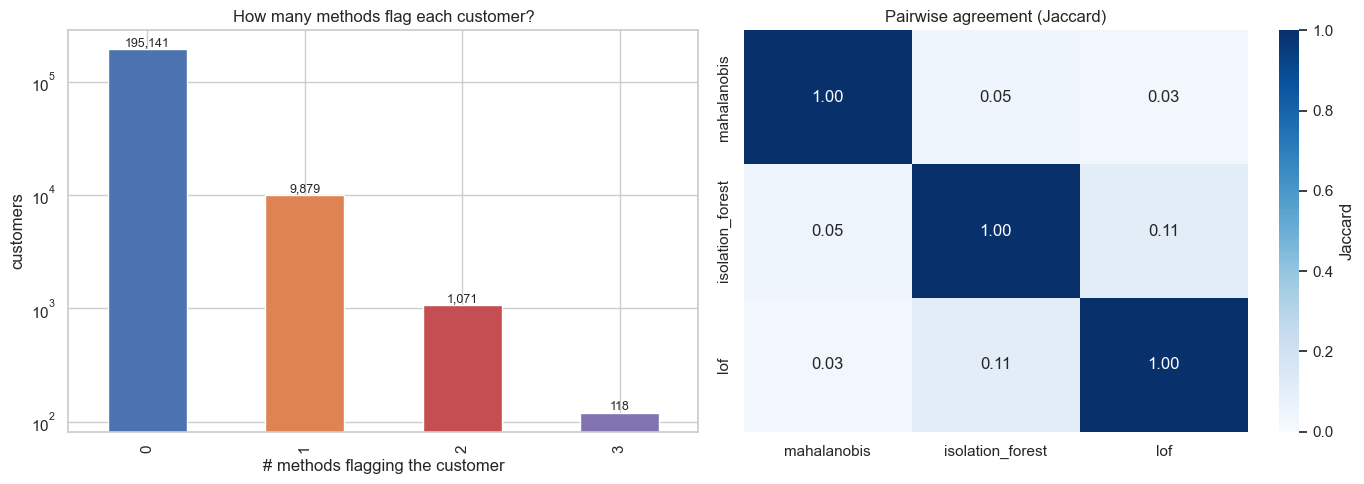

In [22]:
method_cols = ['mahalanobis', 'isolation_forest', 'lof']
jaccard = pd.DataFrame(index=method_cols, columns=method_cols, dtype=float)
for a in method_cols:
    for b in method_cols:
        inter = ((flags[a] == 1) & (flags[b] == 1)).sum()
        union = ((flags[a] == 1) | (flags[b] == 1)).sum()
        jaccard.loc[a, b] = inter / union if union else np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vote_counts.plot(
    kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#C44E52', '#8172B2'],
)
axes[0].set_title('How many methods flag each customer?')
axes[0].set_xlabel('# methods flagging the customer')
axes[0].set_ylabel('customers')
axes[0].set_yscale('log')
for i, v in enumerate(vote_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

sns.heatmap(
    jaccard.astype(float), annot=True, fmt='.2f', cmap='Blues',
    vmin=0, vmax=1, ax=axes[1], cbar_kws={'label': 'Jaccard'},
)
axes[1].set_title('Pairwise agreement (Jaccard)')
fig.tight_layout()
save_figure(fig, 'outlier_method_agreement.png')
plt.show()

In [23]:
profile = pd.DataFrame({
    'inliers (mean)': X_raw[~consensus_mask].mean(),
    'consensus outliers (mean)': X_raw[consensus_mask].mean(),
})
profile['ratio (out / in)'] = profile['consensus outliers (mean)'] / profile['inliers (mean)']
profile.round(3)

,inliers (mean),consensus outliers (mean),ratio (out / in)
total_orders,16.598,4.000,0.241
avg_days_between_orders,15.451,11.452,0.741
avg_order_hour,13.586,12.992,0.956
order_variability,47.460,1.667,0.035
avg_basket_size,9.953,8.121,0.816
reorder_rate,0.432,0.293,0.677


Figure saved -> /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/visualizations/outliers_consensus_pca.png


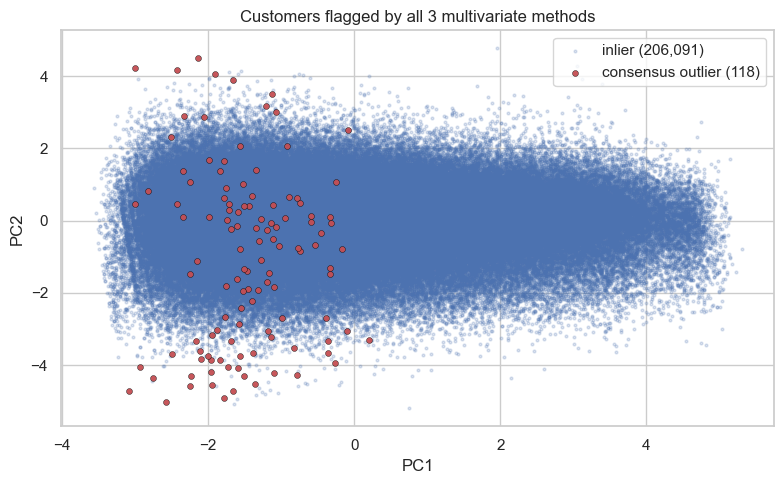

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter_in = ax.scatter(
    X_pca[~consensus_mask, 0], X_pca[~consensus_mask, 1],
    s=4, alpha=0.2, color='#4C72B0', label=f'inlier ({(~consensus_mask).sum():,})',
)
scatter_out = ax.scatter(
    X_pca[consensus_mask, 0], X_pca[consensus_mask, 1],
    s=18, alpha=0.95, color='#C44E52', edgecolor='black', linewidth=0.3,
    label=f'consensus outlier ({consensus_mask.sum():,})',
)
ax.set_title('Customers flagged by all 3 multivariate methods')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='upper right')
fig.tight_layout()
save_figure(fig, 'outliers_consensus_pca.png')
plt.show()

## 6. Persist results

We write a per-customer outlier flag table to `artifacts/customer_outlier_flags.csv` and the univariate-rule summary to `artifacts/outlier_univariate_summary.csv` so downstream notebooks (or the final report) can reuse them.

In [25]:
outlier_table = customer_features[['user_id'] + FEATURES].copy()
outlier_table['mahalanobis_d2'] = mahal_d2
outlier_table['isolation_forest_score'] = iso_score
outlier_table['lof_score'] = lof_score
outlier_table['mahalanobis_outlier'] = mahal_outlier.astype(int)
outlier_table['isolation_forest_outlier'] = iso_outlier.astype(int)
outlier_table['lof_outlier'] = lof_outlier.astype(int)
outlier_table['n_methods_flagging'] = flags['n_methods'].values
outlier_table['consensus_outlier'] = consensus_mask.astype(int)

save_artifact(outlier_table, 'customer_outlier_flags.csv')
save_artifact(univariate_summary, 'outlier_univariate_summary.csv')

print('\nFinal counts')
print('-' * 40)
print(f'customers analysed       : {len(outlier_table):,}')
print(f'mahalanobis outliers     : {mahal_outlier.sum():,}')
print(f'isolation forest outliers: {iso_outlier.sum():,}')
print(f'LOF outliers             : {lof_outlier.sum():,}')
print(f'consensus (all 3)        : {consensus_mask.sum():,}')

Artifact saved -> /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/artifacts/customer_outlier_flags.csv
Artifact saved -> /Users/uditgupta-om/IdeaProjects/255_datamining/CMPE_255_DataMining_MarketAnalysis/artifacts/outlier_univariate_summary.csv

Final counts
----------------------------------------
customers analysed       : 206,209
mahalanobis outliers     : 4,125
isolation forest outliers: 4,125
LOF outliers             : 4,125
consensus (all 3)        : 118


### Takeaways
- The right-skewed features (`total_orders`, `order_variability`, `avg_basket_size`) account for most of the IQR/Z-score flags but largely describe heavy users rather than "bad" data.
- Multivariate methods agree most strongly along the **edges of PC1**, where customers combine very high order counts with unusual basket sizes or reorder rates.
- The consensus outlier set is small (typically ~1% of users) but their average feature ratios show they place far more orders, with much larger and more reorder-heavy baskets — a sensible cohort to either down-weight before clustering or study separately as "power-user" segment.